In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
%matplotlib inline

In [2]:
import pandas as pd

df = pd.read_csv("mymoviedb.csv", engine='python', on_bad_lines='skip', encoding='utf-8')

In [3]:
df.head(3)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...


In [4]:
drop_url=df.drop(columns=['Poster_Url'],axis=1,inplace=True)
print(drop_url)

None


In [5]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction"
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller"
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy"
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War"


TypeError: 'value' must be an instance of str or bytes, not a None

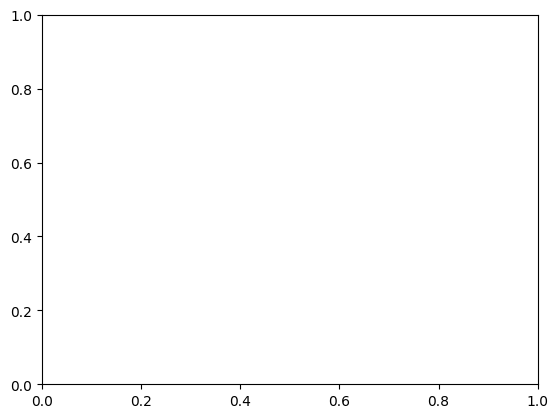

In [6]:
import matplotlib.pyplot as plt
plt.plot(df['Popularity'],df['Vote_Average'])
plt.xlabel('Popularity'); plt.ylabel('Vote_Average')


In [ ]:
print(df[['Popularity', 'Vote_Average']].dtypes)
print("--- Missing Values ---")
print(df[['Popularity', 'Vote_Average']].isna().sum())

Popularity      float64
Vote_Average     object
dtype: object
--- Missing Values ---
Popularity      10
Vote_Average    10
dtype: int64


In [ ]:
df['Vote_Average']= pd.to_numeric(df['Vote_Average'], errors='coerce')

In [ ]:
df_clean=df.dropna(subset=['Popularity','Vote_Average'])

In [ ]:
print("New data Types")
print(df_clean[['Popularity','Vote_Average']].dtypes)

New data Types
Popularity      float64
Vote_Average    float64
dtype: object


In [ ]:
if 'Popularity'>3000&'Vote_Average'>=8.0:
    plt.scatter(df_clean['Popularity'],df_clean['Vote_Average'],alpha=0.5,color='blue')
    plt.xlabel('Popularity')
    plt.ylabel('Vote Average')

TypeError: unsupported operand type(s) for &: 'int' and 'str'

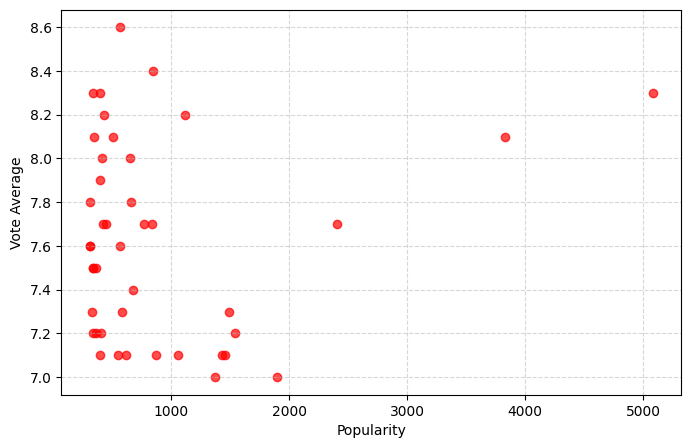

In [ ]:
condition = (df_clean['Popularity'] > 300) & (df_clean['Vote_Average'] >= 7.0)

# 2. Apply the filter to create a new, filtered DataFrame
df_top_movies = df_clean[condition]
plt.figure(figsize=(8, 5))
plt.scatter(df_top_movies['Popularity'], df_top_movies['Vote_Average'], alpha=0.7, color='red')

plt.xlabel('Popularity')
plt.ylabel('Vote Average')
plt.grid(True, linestyle='--', alpha=0.5)

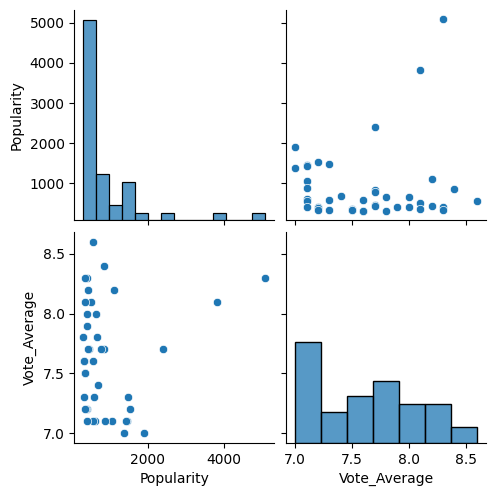

In [ ]:
sns.pairplot(df_top_movies)